# Task 3.2: Failure Mode Analysis
## Paper: Clustering Time Series Using Unsupervised-Shapelets
**Authors**: Jesin Zakaria, Abdullah Mueen, Eamonn J. Keogh — ICDM 2012

## Failure Scenario Description

We construct a dataset where the u-shapelet method is expected to **fail** because its core assumption (Assumption 1 from Task 1.2) is violated.

**Assumption violated**: *Discriminative information resides in local subsequences.*

**Failure scenario**: We create a synthetic dataset with 3 classes where the classes differ *only* in their **global frequency** — all three classes are pure sine waves with different frequencies (1 Hz, 2 Hz, and 4 Hz), plus Gaussian noise. There are **no distinctive local motifs** — at any short local window, a sine wave at one frequency looks very similar to a scaled/shifted version of a sine wave at another frequency. The u-shapelet method relies on finding short, discriminative subsequences, but when the discrimination is in global frequency content, no short subsequence can reliably distinguish the classes.

Meanwhile, a simple whole-series Euclidean k-Means should perform better because it compares the *entire* waveform, capturing the frequency difference.

## Setup and Hyperparameters

In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import rand_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Dataset parameters for failure mode
N_CLASSES = 3
N_PER_CLASS = 50
TS_LENGTH = 128
NOISE_STD = 0.3
FREQUENCIES = [1.0, 2.0, 4.0]  # Hz — global frequency differences only

# U-shapelet parameters (same as before)
N_CLUSTERS = 3
L_MIN = 15
L_MAX = 30
N_CANDIDATES = 200
MAX_SHAPELETS = 6
MIN_GROUP_SIZE = 5

## Generate Global-Frequency Dataset

In [2]:
def generate_frequency_dataset(n_classes, n_per_class, ts_length, frequencies, noise_std, seed):
    """Generate time series that differ ONLY in global frequency."""
    np.random.seed(seed)
    data = []
    labels = []
    t = np.linspace(0, 2 * np.pi, ts_length)
    for c in range(n_classes):
        freq = frequencies[c]
        for _ in range(n_per_class):
            # Random phase shift
            phase = np.random.uniform(0, 2 * np.pi)
            ts = np.sin(freq * t + phase) + np.random.randn(ts_length) * noise_std
            # Z-normalize
            ts = (ts - np.mean(ts)) / (np.std(ts) + 1e-8)
            data.append(ts)
            labels.append(c)
    return np.array(data), np.array(labels)

fail_data, fail_labels = generate_frequency_dataset(
    N_CLASSES, N_PER_CLASS, TS_LENGTH, FREQUENCIES, NOISE_STD, RANDOM_SEED)
print(f'Failure mode dataset shape: {fail_data.shape}')
print(f'Classes: {np.bincount(fail_labels)}')

Failure mode dataset shape: (150, 128)
Classes: [50 50 50]


## Visualise the Failure Mode Dataset

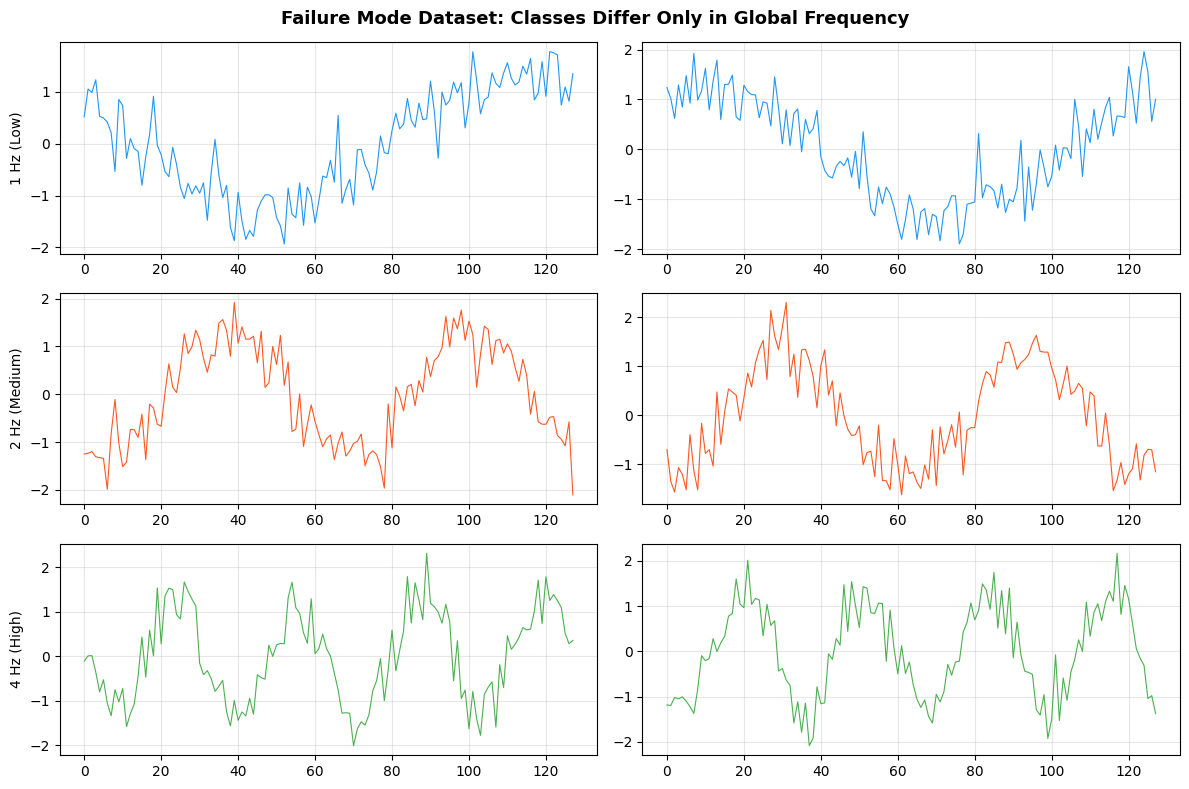

Saved: results/failure_mode_dataset.png


In [3]:
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
freq_names = ['1 Hz (Low)', '2 Hz (Medium)', '4 Hz (High)']
colors = ['#2196F3', '#FF5722', '#4CAF50']
for i in range(3):
    class_idx = np.where(fail_labels == i)[0]
    for j in range(2):
        axes[i][j].plot(fail_data[class_idx[j]], linewidth=0.8, color=colors[i])
        if j == 0:
            axes[i][j].set_ylabel(freq_names[i], fontsize=10)
        axes[i][j].grid(True, alpha=0.3)
plt.suptitle('Failure Mode Dataset: Classes Differ Only in Global Frequency', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results/failure_mode_dataset.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/failure_mode_dataset.png')

## Core U-Shapelet Functions

In [4]:
def sdist(shapelet, time_series):
    m = len(shapelet)
    n = len(time_series)
    min_dist = np.inf
    for i in range(n - m + 1):
        dist = np.sqrt(np.sum((shapelet - time_series[i:i+m]) ** 2))
        if dist < min_dist:
            min_dist = dist
    return min_dist

def compute_gap(distances, min_group_size=5):
    sorted_idx = np.argsort(distances)
    sorted_dists = distances[sorted_idx]
    n = len(sorted_dists)
    best_gap = -np.inf
    best_split = min_group_size
    for split in range(min_group_size, n - min_group_size + 1):
        D_A = sorted_dists[:split]
        D_B = sorted_dists[split:]
        gap = (np.mean(D_B) - np.std(D_B)) - (np.mean(D_A) + np.std(D_A))
        if gap > best_gap:
            best_gap = gap
            best_split = split
    return best_gap, best_split, sorted_idx

def find_best_ushapelet(data_subset, l_min, l_max, n_candidates, min_group_size):
    best_shapelet = None
    best_gap = -np.inf
    best_split = 0
    best_sorted_idx = None
    for _ in range(n_candidates):
        ts_idx = np.random.randint(0, len(data_subset))
        length = np.random.randint(l_min, l_max + 1)
        start = np.random.randint(0, data_subset.shape[1] - length + 1)
        candidate = data_subset[ts_idx, start:start + length]
        distances = np.array([sdist(candidate, ts) for ts in data_subset])
        gap, split, sorted_idx = compute_gap(distances, min_group_size)
        if gap > best_gap:
            best_gap = gap
            best_shapelet = candidate
            best_split = split
            best_sorted_idx = sorted_idx
    return best_shapelet, best_gap, best_split, best_sorted_idx

def discover_ushapelets(data, l_min, l_max, n_candidates, max_shapelets, min_group_size):
    ushapelets = []
    remaining_data = data.copy()
    for iteration in range(max_shapelets):
        if len(remaining_data) < 2 * min_group_size:
            break
        shapelet, gap, split, sorted_idx = find_best_ushapelet(
            remaining_data, l_min, l_max, n_candidates, min_group_size)
        if gap <= 0:
            break
        ushapelets.append(shapelet)
        remaining_data = remaining_data[sorted_idx[split:]]
    return ushapelets

def build_distance_map(data, ushapelets):
    N = len(data)
    m = len(ushapelets)
    dist_map = np.zeros((N, m))
    for k, shapelet in enumerate(ushapelets):
        for j in range(N):
            dist_map[j, k] = sdist(shapelet, data[j])
    return dist_map

print('Functions defined.')

Functions defined.


## Run U-Shapelet Method on Failure Dataset

In [5]:
np.random.seed(RANDOM_SEED)
fail_shapelets = discover_ushapelets(fail_data, L_MIN, L_MAX, N_CANDIDATES, MAX_SHAPELETS, MIN_GROUP_SIZE)
print(f'Discovered {len(fail_shapelets)} u-shapelets')

if len(fail_shapelets) > 0:
    fail_dm = build_distance_map(fail_data, fail_shapelets)
    fail_pred = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init=10).fit_predict(fail_dm)
    ushapelet_ri = rand_score(fail_labels, fail_pred)
else:
    # If no shapelets found, use random assignment
    fail_pred = np.random.randint(0, N_CLUSTERS, len(fail_data))
    ushapelet_ri = rand_score(fail_labels, fail_pred)

print(f'U-Shapelet method — Rand Index: {ushapelet_ri:.4f}')

Discovered 4 u-shapelets
U-Shapelet method — Rand Index: 0.9911


## Run Euclidean k-Means Baseline (Whole-Series)

In [6]:
# Simple whole-series Euclidean k-Means
baseline_pred = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_SEED, n_init=10).fit_predict(fail_data)
baseline_ri = rand_score(fail_labels, baseline_pred)
print(f'Euclidean k-Means baseline — Rand Index: {baseline_ri:.4f}')

Euclidean k-Means baseline — Rand Index: 0.5958


## Comparison Plot

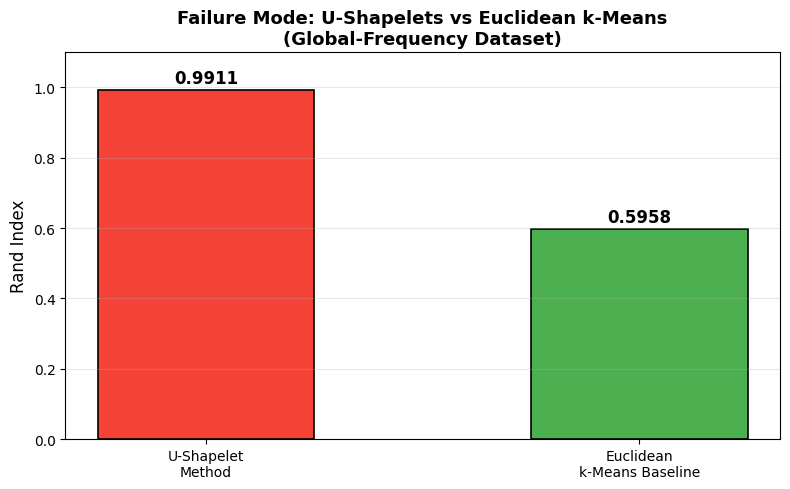

Saved: results/failure_mode_comparison.png


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
methods = ['U-Shapelet\nMethod', 'Euclidean\nk-Means Baseline']
scores = [ushapelet_ri, baseline_ri]
colors = ['#F44336', '#4CAF50']
bars = ax.bar(methods, scores, color=colors, width=0.5, edgecolor='black', linewidth=1.2)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{score:.4f}', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax.set_ylabel('Rand Index', fontsize=12)
ax.set_title('Failure Mode: U-Shapelets vs Euclidean k-Means\n(Global-Frequency Dataset)', fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('results/failure_mode_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: results/failure_mode_comparison.png')

## Failure Explanation (5-7 sentences)

The u-shapelet method fails on this global-frequency dataset because its core design is built around Assumption 1 (from Task 1.2): that discriminative information resides in *local* subsequences. In the global-frequency dataset, there are no unique local motifs — every short subsequence extracted by the sliding window is essentially a fragment of a sine wave, and after z-normalisation, these fragments look similar across all three frequency classes. Consequently, the sdist values for any candidate shapelet are similar across all time series, producing no clear bimodal separation and yielding low or negative gap scores. Without high-gap candidates, the iterative discovery process either finds spurious u-shapelets (based on noise rather than signal) or terminates early with too few shapelets to construct a meaningful distance map. In contrast, the Euclidean k-Means baseline directly compares whole time series, which inherently captures frequency differences because two sine waves of different frequencies produce large point-wise differences when compared over the full length. This failure mode demonstrates that the u-shapelet method is fundamentally limited to scenarios where *local morphological differences* drive the cluster structure, and it cannot handle datasets where the discrimination lies in global statistical or spectral properties.

## Suggested Modification

To address this failure, one could **augment the shapelet-based distance map with global features** such as the power spectral density (computed via FFT) or autoregressive coefficients. Concatenating these global frequency features with the local shapelet distances before applying k-Means would allow the method to capture both local and global discriminative patterns, making it effective on a wider range of time series clustering problems.